# YouTube Spam Collection Classification

<img src="https://cdn.tgdd.vn/Files/2022/12/14/1495470/h2_1280x720-800-resize.jpg">

## 🎯 Project Objective

The objective of this project is to develop a machine learning model
that classifies YouTube comments as spam or non-spam (ham).

The project focuses on applying classical machine learning techniques
combined with text vectorization methods to achieve reliable spam detection.

In [92]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib

## 📊 Dataset Description

The dataset used in this project is the YouTube Spam Collection Dataset.

It contains 1,956 user comments collected from multiple YouTube videos.
Each comment is labeled as either spam (1) or non-spam (0).

In [56]:
data_path = "/kaggle/input/images"

In [57]:
files = ["Youtube01-Psy.csv",
         "Youtube02-KatyPerry.csv",
         "Youtube03-LMFAO.csv",
         "Youtube04-Eminem.csv",
         "Youtube05-Shakira.csv"]

In [58]:
df_list = []

for file in files:
    temp_df = pd.read_csv(os.path.join(data_path, file))
    df_list.append(temp_df)

In [59]:
df = pd.concat(df_list, ignore_index=True)

## 🔍 Exploratory Data Analysis (EDA)

Initial exploration of the dataset was conducted to understand its structure,
size, and overall characteristics.

The dataset contains 1,956 YouTube comments labeled as either spam or non-spam (ham).
Basic inspection confirmed that the dataset is clean and suitable for
text classification tasks.

In [60]:
df.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1


In [61]:
df.tail()

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
1951,_2viQ_Qnc6-bMSjqyL1NKj57ROicCSJV5SwTrw-RFFA,Katie Mettam,2013-07-13T13:27:39.441000,I love this song because we sing it at Camp al...,0
1952,_2viQ_Qnc6-pY-1yR6K2FhmC5i48-WuNx5CumlHLDAI,Sabina Pearson-Smith,2013-07-13T13:14:30.021000,I love this song for two reasons: 1.it is abou...,0
1953,_2viQ_Qnc6_k_n_Bse9zVhJP8tJReZpo8uM2uZfnzDs,jeffrey jules,2013-07-13T12:09:31.188000,wow,0
1954,_2viQ_Qnc6_yBt8UGMWyg3vh0PulTqcqyQtdE7d4Fl0,Aishlin Maciel,2013-07-13T11:17:52.308000,Shakira u are so wiredo,0
1955,_2viQ_Qnc685RPw1aSa1tfrIuHXRvAQ2rPT9R06KTqA,Latin Bosch,2013-07-12T22:33:27.916000,Shakira is the best dancer,0


In [62]:
df.shape

(1956, 5)

In [63]:
df.isnull().sum()

COMMENT_ID      0
AUTHOR          0
DATE          245
CONTENT         0
CLASS           0
dtype: int64

In [64]:
df.columns

Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS'], dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   COMMENT_ID  1956 non-null   object
 1   AUTHOR      1956 non-null   object
 2   DATE        1711 non-null   object
 3   CONTENT     1956 non-null   object
 4   CLASS       1956 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 76.5+ KB


## 🧹 Data Preprocessing

The following preprocessing steps were applied:

- Selection of relevant columns
- Column renaming for consistency
- Handling missing values
- Splitting data into features and labels
- Transforming text data using TF-IDF vectorization

Text preprocessing was intentionally kept minimal,
as TF-IDF effectively captures meaningful text patterns.

In [66]:
df = df[["CONTENT", "CLASS"]].copy()

In [67]:
df.head()

,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,watch?v=vtaRGgvGtWQ Check this out .﻿,1


In [68]:
df = df.rename(columns={"CONTENT": "comment", "CLASS": "label"})

In [69]:
df.head()

,comment,label
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,watch?v=vtaRGgvGtWQ Check this out .﻿,1


## 📊 Class Distribution Analysis

Class distribution analysis shows that the dataset is nearly balanced,
with a similar number of spam and non-spam comments.

This balance is beneficial for supervised learning, as it reduces the
risk of bias toward one class during model training.

In [70]:
df["label"].value_counts()

label
1    1005
0     951
Name: count, dtype: int64

/tmp/ipykernel_55/2104877009.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="spring")


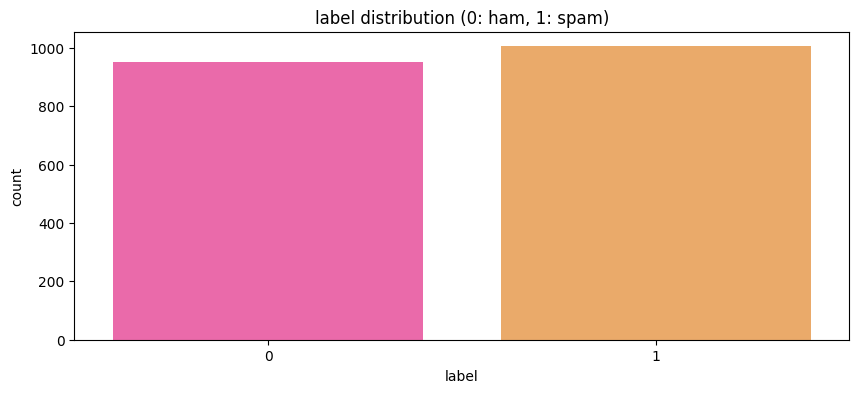

In [71]:
sns.countplot(x="label", data=df, palette="spring")
plt.title("label distribution (0: ham, 1: spam)")
plt.show()

In [72]:
x = df["comment"]

In [73]:
y = df["label"]

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [75]:
x_train.shape, x_test.shape

((1564,), (392,))

In [76]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2))

In [77]:
x_train_vec = vectorizer.fit_transform(x_train)

In [78]:
x_test_vec = vectorizer.transform(x_test)

In [79]:
x_train_vec.shape

(1564, 5000)

## 🤖 Model Training

Three different machine learning models were trained and evaluated:

- Logistic Regression
- Multinomial Naive Bayes
- Linear Support Vector Machine (SVM)

An 80/20 train-test split was applied to evaluate model performance.


In [80]:
model_lr = LogisticRegression(max_iter=1000)

In [81]:
model_lr.fit(x_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [82]:
y_pred_lr = model_lr.predict(x_test_vec)

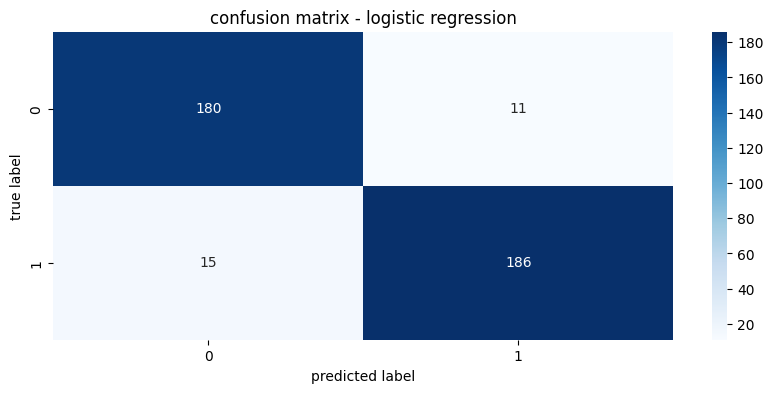

In [83]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues")

plt.title("confusion matrix - logistic regression")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.show()

In [84]:
model_nb = MultinomialNB()

In [85]:
model_nb.fit(x_train_vec, y_train)

MultinomialNB()

In [86]:
y_pred_nb = model_nb.predict(x_test_vec)

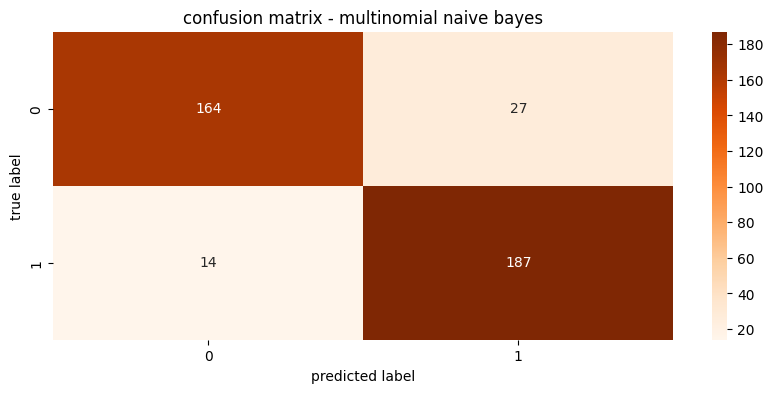

In [103]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb,annot=True,fmt="d",cmap="Oranges")

plt.title("confusion matrix - multinomial naive bayes")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.show()

In [87]:
model_svm = LinearSVC(random_state=42)

In [88]:
model_svm.fit(x_train_vec, y_train)

LinearSVC(random_state=42)

In [89]:
y_pred_svm = model_svm.predict(x_test_vec)

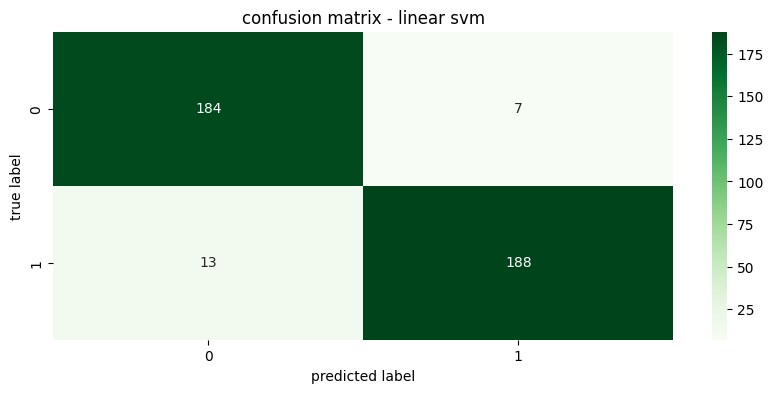

In [99]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm,annot=True,fmt="d",cmap="Greens")

plt.title("confusion matrix - linear svm")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.show()

## 📊 Results Comparison

Model performance was compared using accuracy, precision, recall,
and F1-score (macro average).

Linear SVM achieved the best overall performance, followed by
Logistic Regression and Multinomial Naive Bayes.


In [94]:
models = {"logistic regression": LogisticRegression(max_iter=1000, random_state=42),
          "multinomial nb": MultinomialNB(),
          "linear svm": LinearSVC(random_state=42)}

rows = []

for model_name, model in models.items():
    model.fit(x_train_vec, y_train)
    y_pred = model.predict(x_test_vec)

    rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1-score (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0)})

results_df = pd.DataFrame(rows).sort_values(by="accuracy", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision (macro),recall (macro),f1-score (macro)
0,linear svm,0.948980,0.949056,0.949337,0.948974
1,logistic regression,0.933673,0.933620,0.933891,0.933658
2,multinomial nb,0.895408,0.897590,0.894494,0.895047


In [96]:
joblib.dump(model_svm, "final_spam_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']